# NLP Projesi: Mobil Uygulama Yorum Analizi
Bu projede App Store / Google Play'de yazılan kullanıcı yorumlarını tema ve şikayet bazında ayırmaya hazırlık amacıyla metin ön işleme adımları ve Zipf Yasası analizi gerçekleştirilmiştir.

## 1. Veri Seti Seçimi ve Raporlama
- **Kaynak**: Veri seti yerel dizinden `app_store_reviews.csv` isimli dosyadan temin edilmiştir.
- **Boyut**: Toplam 322 döküman (yorum) içermektedir. Dosya boyutu yaklaşık 41 KB'dır. Orijinal formatı CSV'dir.
- **Sütun Yapısı**: `date`, `platform`, `country`, `review`, `star`, `user_id`, `issue_flag`, `likes_count`, `dislike_count`, `label` şeklindedir.
Model eğitimi için temizlenmiş metin verisini içeren `review` kolonu hedef alınmıştır.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import re
import string
from collections import Counter

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

df = pd.read_csv('app_store_reviews.csv', sep=';')
df.head()

,date,platform,country,review,star,user_id,issue_flag,likes_count,dislike_count,label
0,7.07.2023,iOS,Australia,Love the itinerary sharing feature. It makes p...,5,13c95471-be12-42f6-95d1-fa3dd104909b,No,1,1,NaN
1,12.08.2023,Android,India,"The premium price is a bit high, but the featu...",4,945725ef-7277-4884-b717-9259af1df8d2,No,2,2,NaN
2,12.09.2023,iOS,UK,I can't share my trip details via WhatsApp dir...,5,e3d956b8-6e00-4099-84ca-f51406e6b3f7,No,5,3,NaN
3,12.07.2023,Android,Brazil,"The price of premium is too high, could be bet...",3,1fa559f7-a707-4f23-97f9-1cb92a0ba85b,No,0,0,NaN
4,24.09.2023,iOS,India,Smooth booking experience.,3,67934645-a9bf-4283-b809-1baa3f067b19,No,2,5,NaN


## 2. Zipf Yasası Analizi
Ön işleme adımlarına geçmeden önce ham verideki kelime frekanslarına dayanarak Zipf Yasası  grafiği çizdirilmektedir.

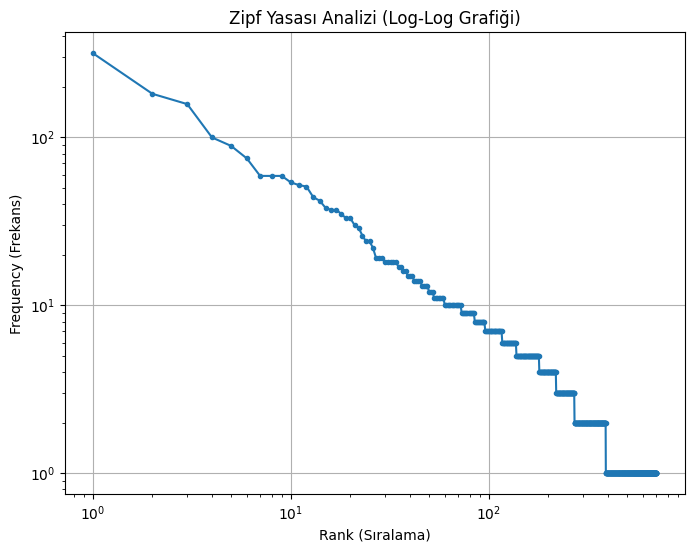

In [2]:
from nltk.tokenize import word_tokenize

text = ' '.join(df['review'].dropna().tolist())
tokens = word_tokenize(text)
word_counts = Counter(tokens)
frequencies = sorted(list(word_counts.values()), reverse=True)
ranks = np.arange(1, len(frequencies) + 1)

plt.figure(figsize=(8, 6))
plt.loglog(ranks, frequencies, marker='.')
plt.title('Zipf Yasası Analizi (Log-Log Grafiği)')
plt.xlabel('Rank (Sıralama)')
plt.ylabel('Frequency (Frekans)')
plt.grid(True)
plt.show()

## 3. Ön İşleme (Pre-processing) Aşamaları
Aşağıdaki adımlarla metinler temizlenip düzenlenecektir.
1. Genel İçerik Temizliği 
2. Lowercasing (Küçük harfe çevirme)
3. Tokenization (Kelimelere ayırma ve noktalama silme, cümle yapısı korunarak)
4. Stop Word Removal (Gereksiz kelimelerin atılması)
5. Lemmatization (Sözlük köküne indirgeme)
6. Stemming (Gövdeye indirgeme)

In [3]:
# Önce/Sonra karşılaştırması için örnek bir metin seçelim
sample_text = df['review'].iloc[2]
print('Orijinal Metin:\n', sample_text)

Orijinal Metin:
 I can't share my trip details via WhatsApp directly, which would be a great feature.


### 3.1. Genel İçerik Temizlik ve Lowercasing

In [4]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'<.*?>', '', text) # HTML etiketlerini temizle
    text = re.sub(r'\d+', '', text)   # Sayıları temizle
    text = text.lower()             # Lowercasing
    return text

df['cleaned_review'] = df['review'].apply(clean_text)
print('Önce:', sample_text)
print('Sonra:', clean_text(sample_text))

Önce: I can't share my trip details via WhatsApp directly, which would be a great feature.
Sonra: i can't share my trip details via whatsapp directly, which would be a great feature.


### 3.2. Tokenization ve Noktalama İşaretlerinin Kaldırılması

In [5]:
def tokenize_text(text):
    # Noktalama işaretlerini kaldırarak tokenize et (cümleleri virgül/nokta olmadan kelime kelime tutar)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    return tokens

df['tokenized_review'] = df['cleaned_review'].apply(tokenize_text)
print('Önce:', clean_text(sample_text))
print('Sonra:', tokenize_text(clean_text(sample_text)))

Önce: i can't share my trip details via whatsapp directly, which would be a great feature.
Sonra: ['i', 'cant', 'share', 'my', 'trip', 'details', 'via', 'whatsapp', 'directly', 'which', 'would', 'be', 'a', 'great', 'feature']


### 3.3. Stop Word Removal

In [6]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['no_stopwords_review'] = df['tokenized_review'].apply(remove_stopwords)
print('Önce:', tokenize_text(clean_text(sample_text)))
print('Sonra:', remove_stopwords(tokenize_text(clean_text(sample_text))))

Önce: ['i', 'cant', 'share', 'my', 'trip', 'details', 'via', 'whatsapp', 'directly', 'which', 'would', 'be', 'a', 'great', 'feature']
Sonra: ['cant', 'share', 'trip', 'details', 'via', 'whatsapp', 'directly', 'would', 'great', 'feature']


### 3.4. Lemmatization

In [7]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
def lemmatize_text(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

df['lemmatized_review'] = df['no_stopwords_review'].apply(lemmatize_text)
print('Önce:', remove_stopwords(tokenize_text(clean_text(sample_text))))
print('Sonra:', lemmatize_text(remove_stopwords(tokenize_text(clean_text(sample_text)))))

Önce: ['cant', 'share', 'trip', 'details', 'via', 'whatsapp', 'directly', 'would', 'great', 'feature']
Sonra: ['cant', 'share', 'trip', 'detail', 'via', 'whatsapp', 'directly', 'would', 'great', 'feature']


### 3.5. Stemming

In [8]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
def stem_text(tokens):
    return [stemmer.stem(word) for word in tokens]

df['stemmed_review'] = df['no_stopwords_review'].apply(stem_text)
print('Önce:', remove_stopwords(tokenize_text(clean_text(sample_text))))
print('Sonra:', stem_text(remove_stopwords(tokenize_text(clean_text(sample_text)))))

Önce: ['cant', 'share', 'trip', 'details', 'via', 'whatsapp', 'directly', 'would', 'great', 'feature']
Sonra: ['cant', 'share', 'trip', 'detail', 'via', 'whatsapp', 'directli', 'would', 'great', 'featur']


## 4. Veri Setlerini Kaydetme (CSV)


In [ ]:
# Listeleri boşlukla birleştirerek string formatında kaydettik
df['lemmatized_text'] = df['lemmatized_review'].apply(lambda x: ' '.join(x))
df['stemmed_text'] = df['stemmed_review'].apply(lambda x: ' '.join(x))

# 1. Ham Veri Seti
df[['date', 'platform', 'country', 'review', 'star', 'user_id', 'issue_flag', 'likes_count', 'dislike_count', 'label']].to_csv('ham_veri_seti.csv', index=False, sep=';')

# 2. Stemmed Veri Seti
df_stemmed = df[['date', 'platform', 'country', 'stemmed_text', 'star', 'user_id', 'issue_flag', 'likes_count', 'dislike_count', 'label']]
df_stemmed.to_csv('stemmed_veri_seti.csv', index=False, sep=';')

# 3. Lemmatized Veri Seti
df_lemmatized = df[['date', 'platform', 'country', 'lemmatized_text', 'star', 'user_id', 'issue_flag', 'likes_count', 'dislike_count', 'label']]
df_lemmatized.to_csv('lemmatized_veri_seti.csv', index=False, sep=';')

Veriler başarıyla CSV formatında kaydedildi!
